In [1]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import sdevelo
import warnings
import cellrank
import moscot

(Working on SDEvelo 0.2.12)
2026-01-23 13:19:24


In [2]:
# Read input file
working_directory = "RNA Sequencing Data/"
adata = scanpy.read_h5ad(working_directory + "/velocity_sdevelo.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time', 'sde_velocity_self_transition', 'manual_root', 'manual_end', 'sde_velocity_pseudotime'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'log1p', 'neighbors', 'pca', 'sample_colors', 'sde_velocity_graph', 'sde_velocity_graph_neg', 'sde_velocity_params'
    obsm: 'X_fdl', 'X_pca', 'X_umap', 'sde_velocity_fdl'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'pred_s', 'pred_u', 'sde_velocity', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'


In [3]:
# Suppress warnings

warnings.simplefilter("ignore", category=UserWarning)

       'Cdc25c', 'Cdc45', 'Cdc6', 'Cdca2', 'Cdca3', 'Cdca7', 'Cdca8', 'Chaf1b',
       'Ckap2', 'Ckap5', 'Cks1b', 'Cks2', 'Clspn', 'Ctcf', 'Dlgap5', 'Dscc1',
       'Dtl', 'E2f8', 'Exo1', 'Fen1', 'G2e3', 'Gins2', 'Gmnn', 'Gtse1',
       'Hjurp', 'Hn1', 'Kif23', 'Kif2c', 'Lbr', 'Mcm2', 'Mcm4', 'Mcm5', 'Mcm6',
       'Mlf1ip', 'Msh2', 'Ncapd2', 'Ndc80', 'Nek2', 'Nuf2', 'Pcna', 'Pola1',
       'Pold3', 'Prim1', 'Psrc1', 'Rad51', 'Rad51ap1', 'Rangap1', 'Rfc2',
       'Rpa2', 'Rrm1', 'Slbp', 'Smc4', 'Tacc3', 'Tipin', 'Tmpo', 'Ttk', 'Tyms',
       'Ube2c', 'Ubr7', 'Uhrf1', 'Ung', 'Usp1', 'Wdr76'],
      dtype='object')
       'Apaf1', 'Baiap2',
       ...
       'Tspyl2', 'Vamp8', 'Vdr', 'Vwa5a', 'Wrap73', 'Wwp1', 'Xpc', 'Zbtb16',
       'Zfp365', 'Zmat3'],
      dtype='object', length=134)


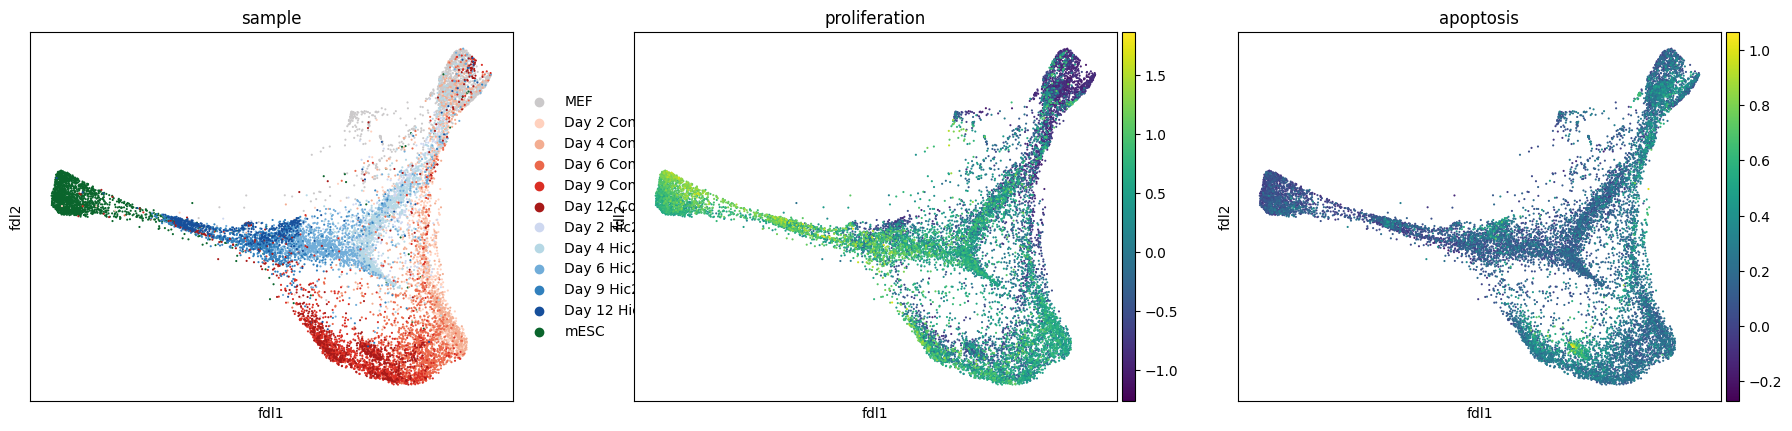

In [4]:
# Create real time kernel

temporal_problem = moscot.problems.time.TemporalProblem(adata)

# Adjust for cell growth and death
temporal_problem = temporal_problem.score_genes_for_marginals(
    gene_set_proliferation="mouse", gene_set_apoptosis="mouse"
)
scanpy.pl.embedding(
    adata, basis="fdl", color=["sample", "proliferation", "apoptosis"]
)

The next steps did not work because sdevelo requires numpy < 2 and jax requires numpy >= 2.

In [5]:
# Create velocity kernel

velocity_kernel = cellrank.kernels.VelocityKernel(adata, vkey="sde_velocity")
velocity_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

  0%|          | 0/12791 [00:00<?, ?cell/s]

VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344]

In [6]:
# Create kernel based on latent time

latent_time_kernel = cellrank.kernels.PseudotimeKernel(adata, time_key = "latent_time")
latent_time_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [7]:
# Kernel based on gene expression similarity

connectivity_kernel = cellrank.kernels.ConnectivityKernel(adata)
connectivity_kernel.compute_transition_matrix()

ConnectivityKernel[n=12791, dnorm=True, key='connectivities']

In [12]:
# Combine all three kernels

combined_kernel = (1/3)*velocity_kernel + (1/3)*latent_time_kernel + (1/3)*connectivity_kernel
combined_kernel.compute_transition_matrix()

(0.333 * VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344] + 0.333 * PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3] + 0.333 * ConnectivityKernel[n=12791, dnorm=True, key='connectivities'])

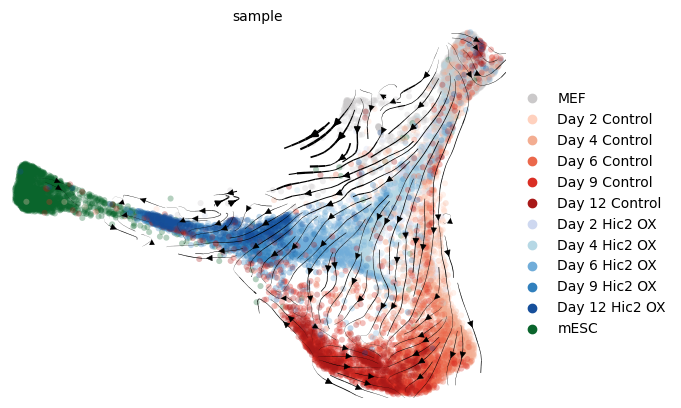

In [13]:
# Plot transition matrix
combined_kernel.plot_projection(basis="fdl", color="sample", legend_loc="right margin")

  0%|          | 0/100 [00:00<?, ?sim/s]

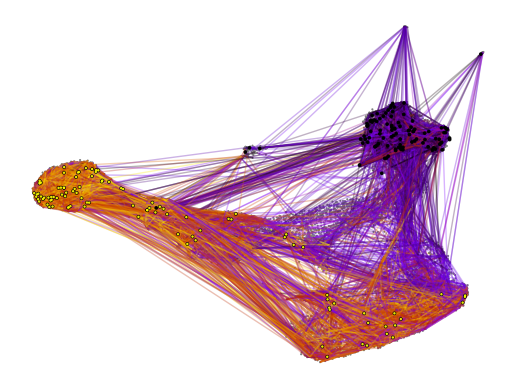

In [14]:
# Simulate random walk

combined_kernel.plot_random_walks(start_ixs={"sample": "MEF"}, max_iter=200, seed=0)

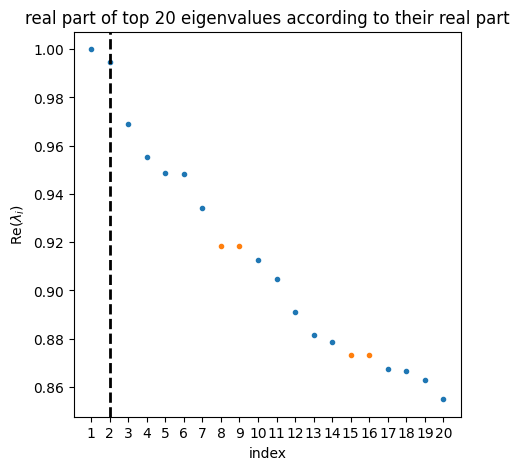

In [16]:
# More advanced estimator

estimator = cellrank.estimators.GPCCA(combined_kernel)
estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

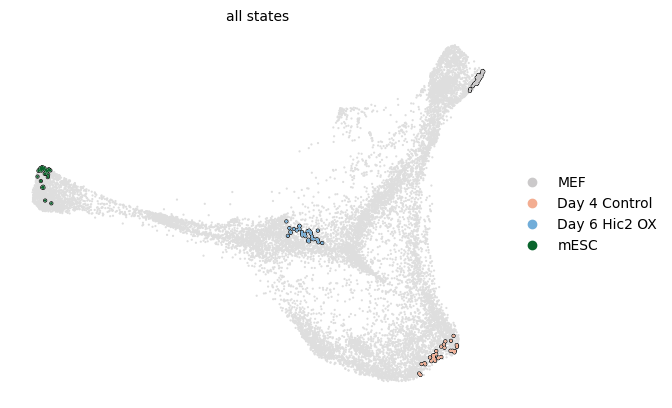

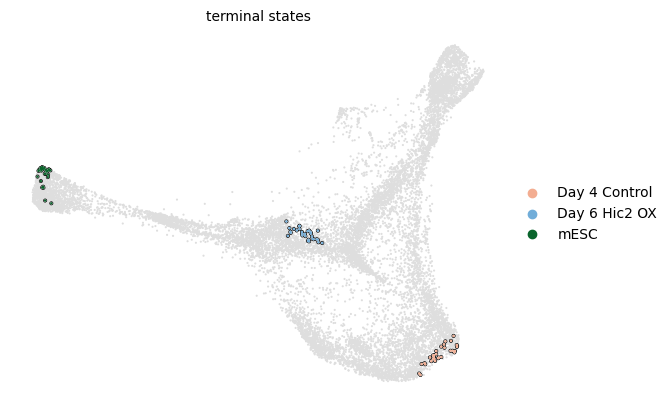

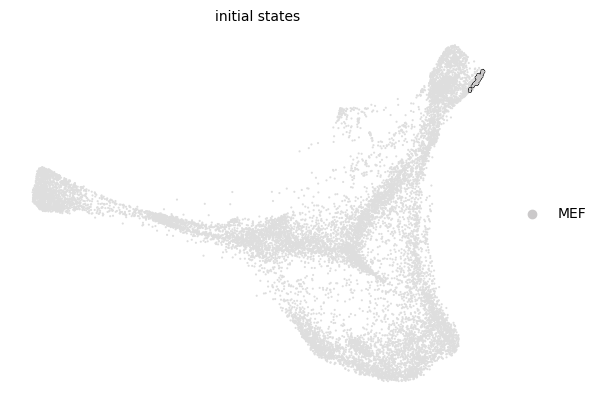

In [17]:
# Cluster

estimator.compute_macrostates(n_states=4, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states

estimator.predict_terminal_states()
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states

estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)
initial_states = estimator.initial_states_memberships.names

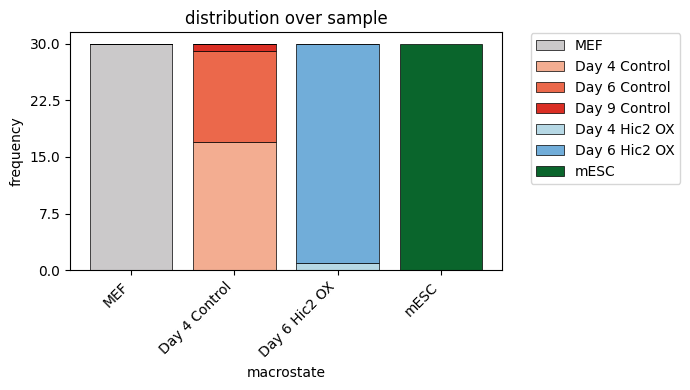

In [18]:
estimator.plot_macrostate_composition(key="sample", figsize=(7, 4))

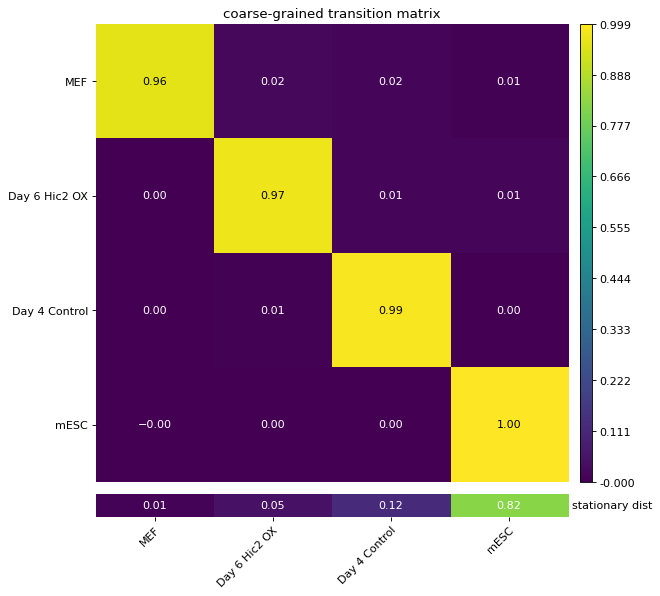

In [19]:
estimator.plot_coarse_T()

  0%|          | 0/3 [00:00<?, ?/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


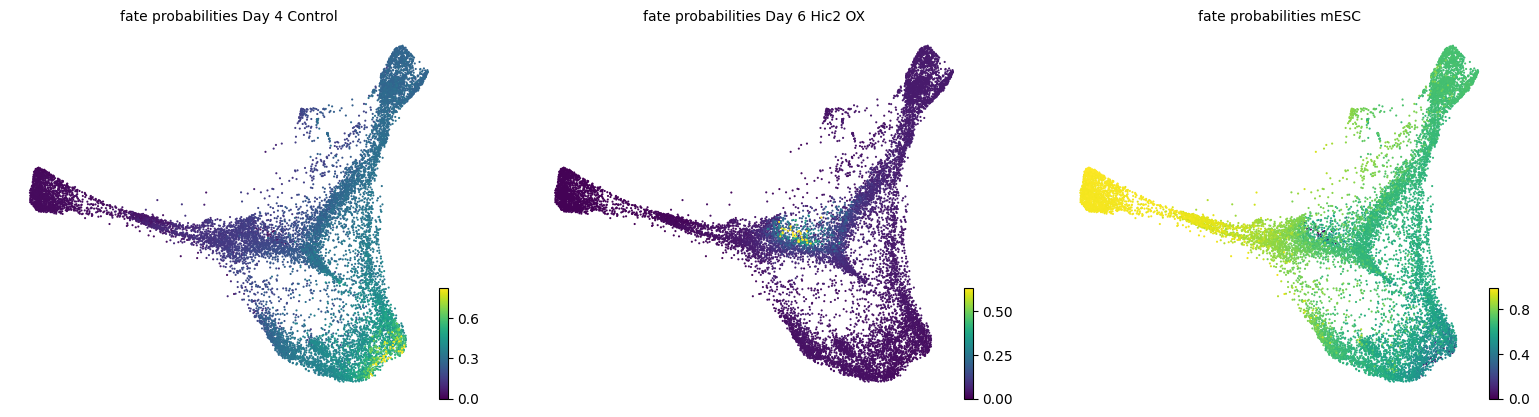

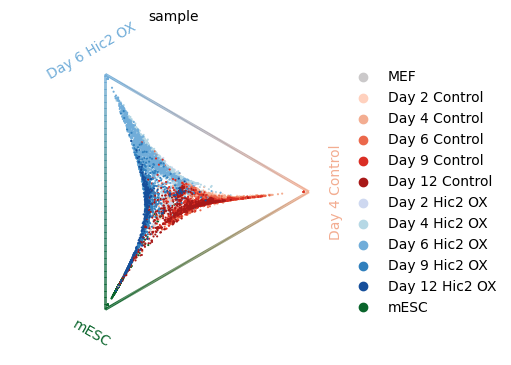

In [21]:
# Estimate fate probabilities

estimator.compute_fate_probabilities()

# Add fate probabilities to adata
for terminal_state in terminal_states:
    adata.obs[f"fate_probabilities_{terminal_state}"] = estimator.fate_probabilities[terminal_state].X.flatten()

estimator.plot_fate_probabilities(same_plot=False, basis="fdl")
cellrank.pl.circular_projection(adata, keys=["sample"], legend_loc="right")

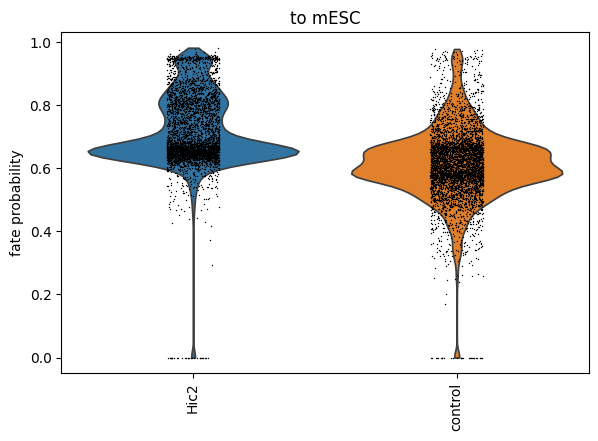

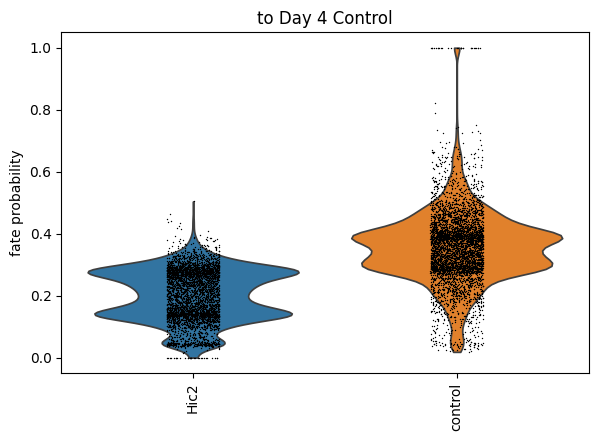

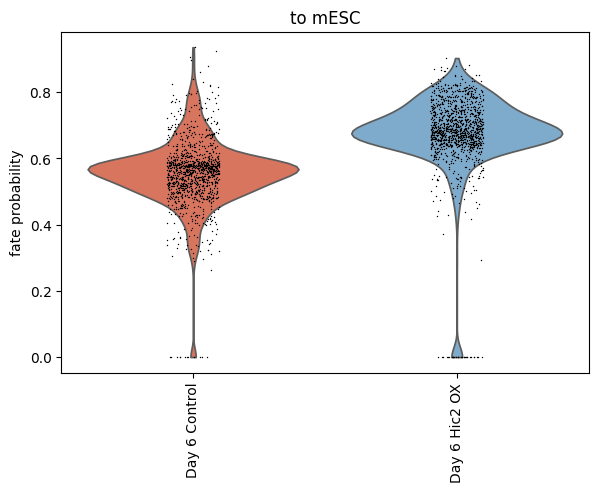

In [32]:
# Aggregate fate probabilities

cellrank.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["mESC"],
    cluster_key="group",
    clusters=["control", "Hic2"],
)

cellrank.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["Day 4 Control"],
    cluster_key="group",
    clusters=["control", "Hic2"],
)

cellrank.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["mESC"],
    cluster_key="sample",
    clusters=["Day 6 Control", "Day 6 Hic2 OX"],
)

In [23]:
# Find driver genes for all terminal states

reprogramming_groups = ["Hic2", "control"]

driver_df = estimator.compute_lineage_drivers(
    cluster_key="group", clusters=reprogramming_groups
)
corr_columns = [state+"_corr" for state in terminal_states]


In [24]:
# Drivers for mESCs
driver_df.sort_values("mESC_corr", ascending=False).head(20)[corr_columns]

,Day 4 Control_corr,Day 6 Hic2 OX_corr,mESC_corr
gene_names,,,
Rbpms2,-0.549161,-0.088536,0.604705
Apoc1,-0.519469,-0.125477,0.595133
Utf1,-0.548516,-0.065376,0.591219
Dppa4,-0.517575,-0.119037,0.589648
Trap1a,-0.488288,-0.156499,0.580773
H2afv,-0.534675,-0.070633,0.580095
Agtrap,-0.534307,-0.028933,0.556650
Fbxo15,-0.573958,0.047831,0.554231
Jarid2,-0.506215,-0.073396,0.552869


In [25]:
# Drivers for Hic2 path
driver_df.sort_values("Day 6 Hic2 OX_corr", ascending=False).head(20)[corr_columns]

,Day 4 Control_corr,Day 6 Hic2 OX_corr,mESC_corr
gene_names,,,
Hbb-y,-0.101661,0.476286,-0.161060
Mfap5,-0.327182,0.417985,0.099431
Krt20,-0.162955,0.408884,-0.061703
Rcan2,-0.211081,0.368400,0.009428
Ddc,-0.312538,0.365929,0.113454
Fgfbp1,-0.528159,0.356664,0.336754
Clu,-0.096584,0.351290,-0.096942
Hck,-0.184953,0.332842,0.002697
Anxa2,-0.385505,0.315517,0.215231


In [26]:
# Drivers for early control path
driver_df.sort_values("Day 4 Control_corr", ascending=False).head(20)[corr_columns]

,Day 4 Control_corr,Day 6 Hic2 OX_corr,mESC_corr
gene_names,,,
Cd24a,0.625710,-0.252444,-0.493231
Tmem238,0.621425,-0.137679,-0.552474
Lmo1,0.619266,-0.253943,-0.485858
Rtn4r,0.616294,-0.233369,-0.494252
Pcolce2,0.603007,-0.228392,-0.483563
Crip2,0.598531,-0.129597,-0.533795
Ctsz,0.592733,-0.051905,-0.571008
Urah,0.583537,-0.203449,-0.477689
Kcnn4,0.580131,-0.209009,-0.471161


In [28]:
# How specific genes correlate with terminal states
genes_of_interest = ["Krtdap", "Krt8", "Krt14", "Nanog", "Tet1", "Cdh1"]
driver_df.loc[genes_of_interest, corr_columns]

,Day 4 Control_corr,Day 6 Hic2 OX_corr,mESC_corr
gene_names,,,
Krtdap,0.017508,0.314550,-0.192010
Krt8,0.358935,-0.126700,-0.292956
Krt14,0.379401,-0.147003,-0.302416
Nanog,-0.311014,-0.138547,0.391457
Tet1,-0.449564,-0.168646,0.548326
Cdh1,0.242678,-0.221527,-0.122786


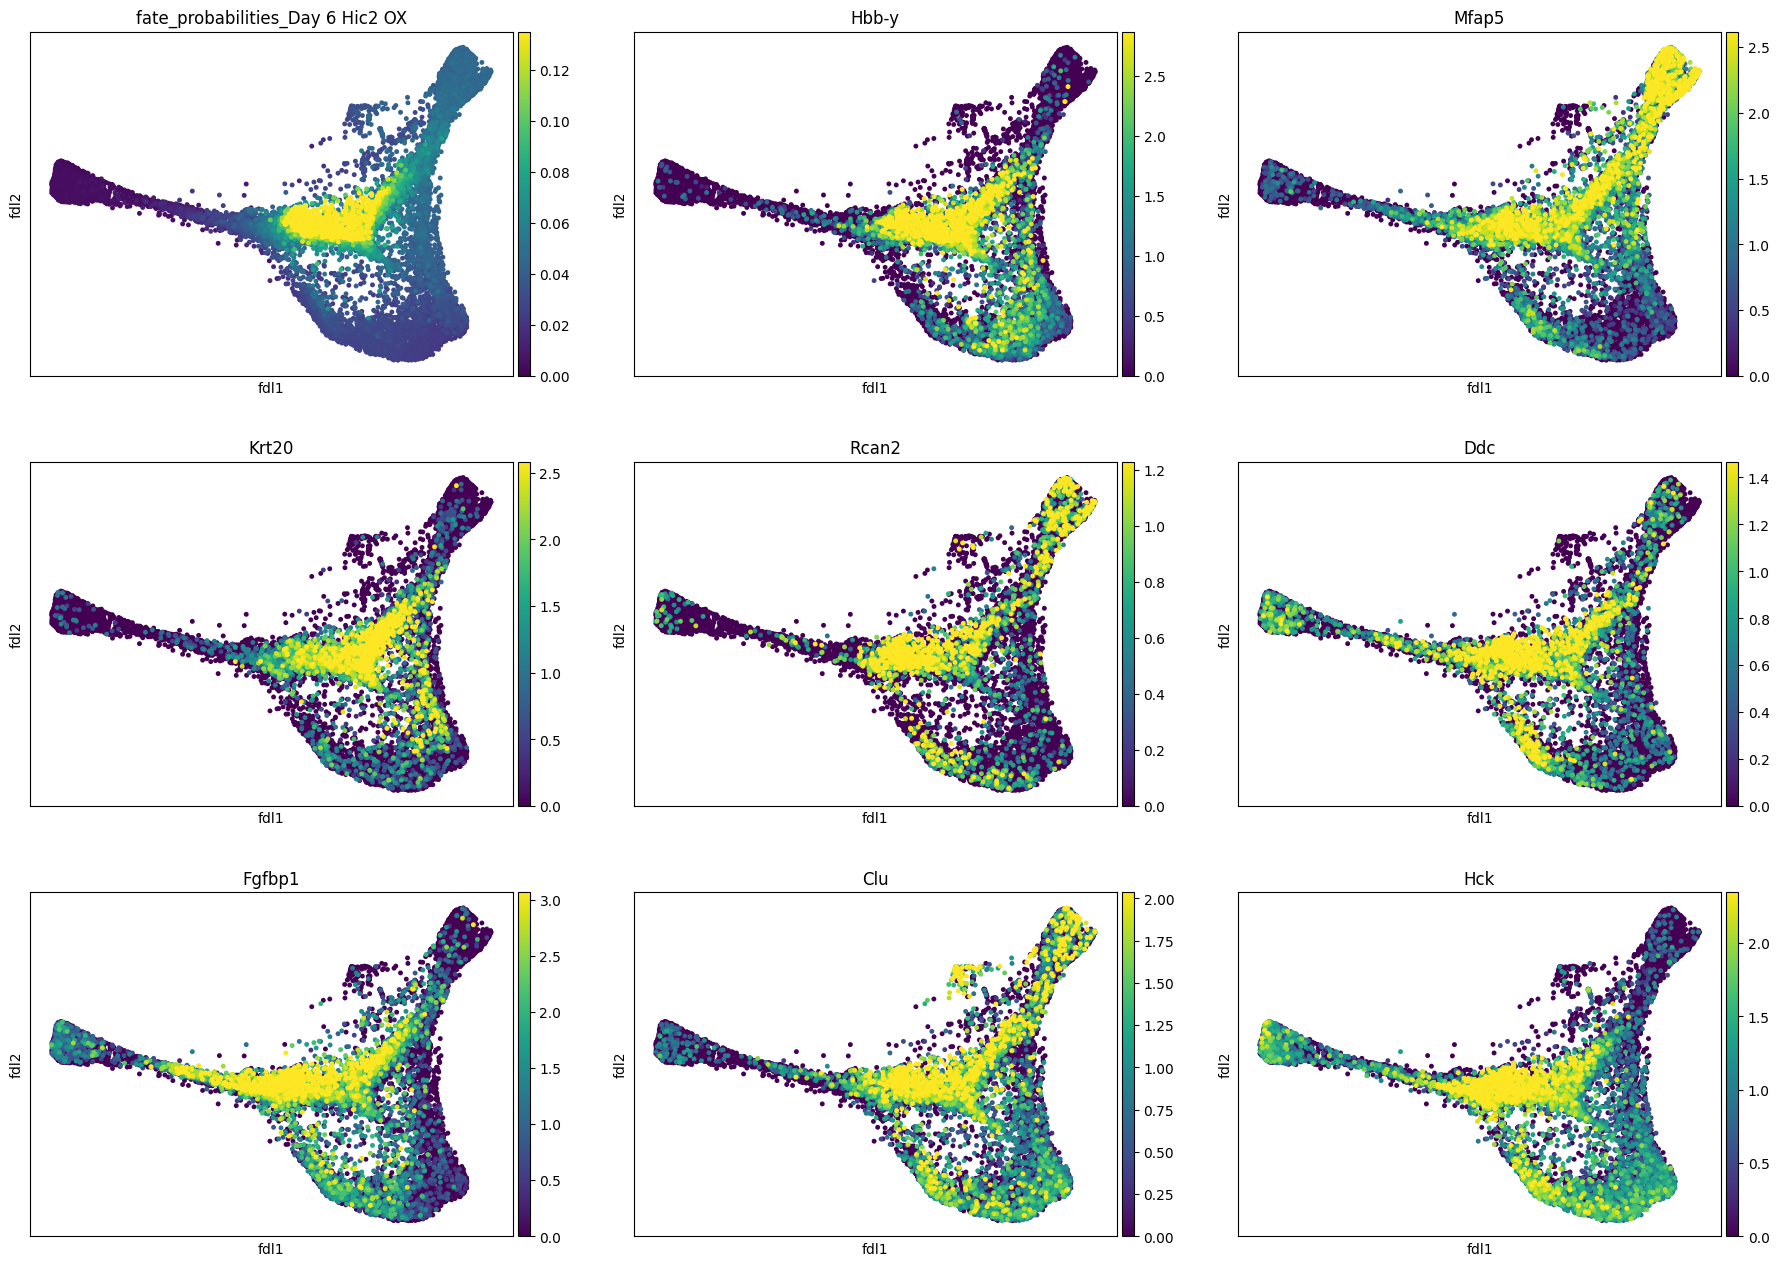

In [33]:
# Visualize driver genes for the Hic2 path

terminal_state = "Day 6 Hic2 OX"
scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=[f"fate_probabilities_{terminal_state}"] + list(driver_df.sort_values(f"{terminal_state}_corr", ascending=False).index[:8]),
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)

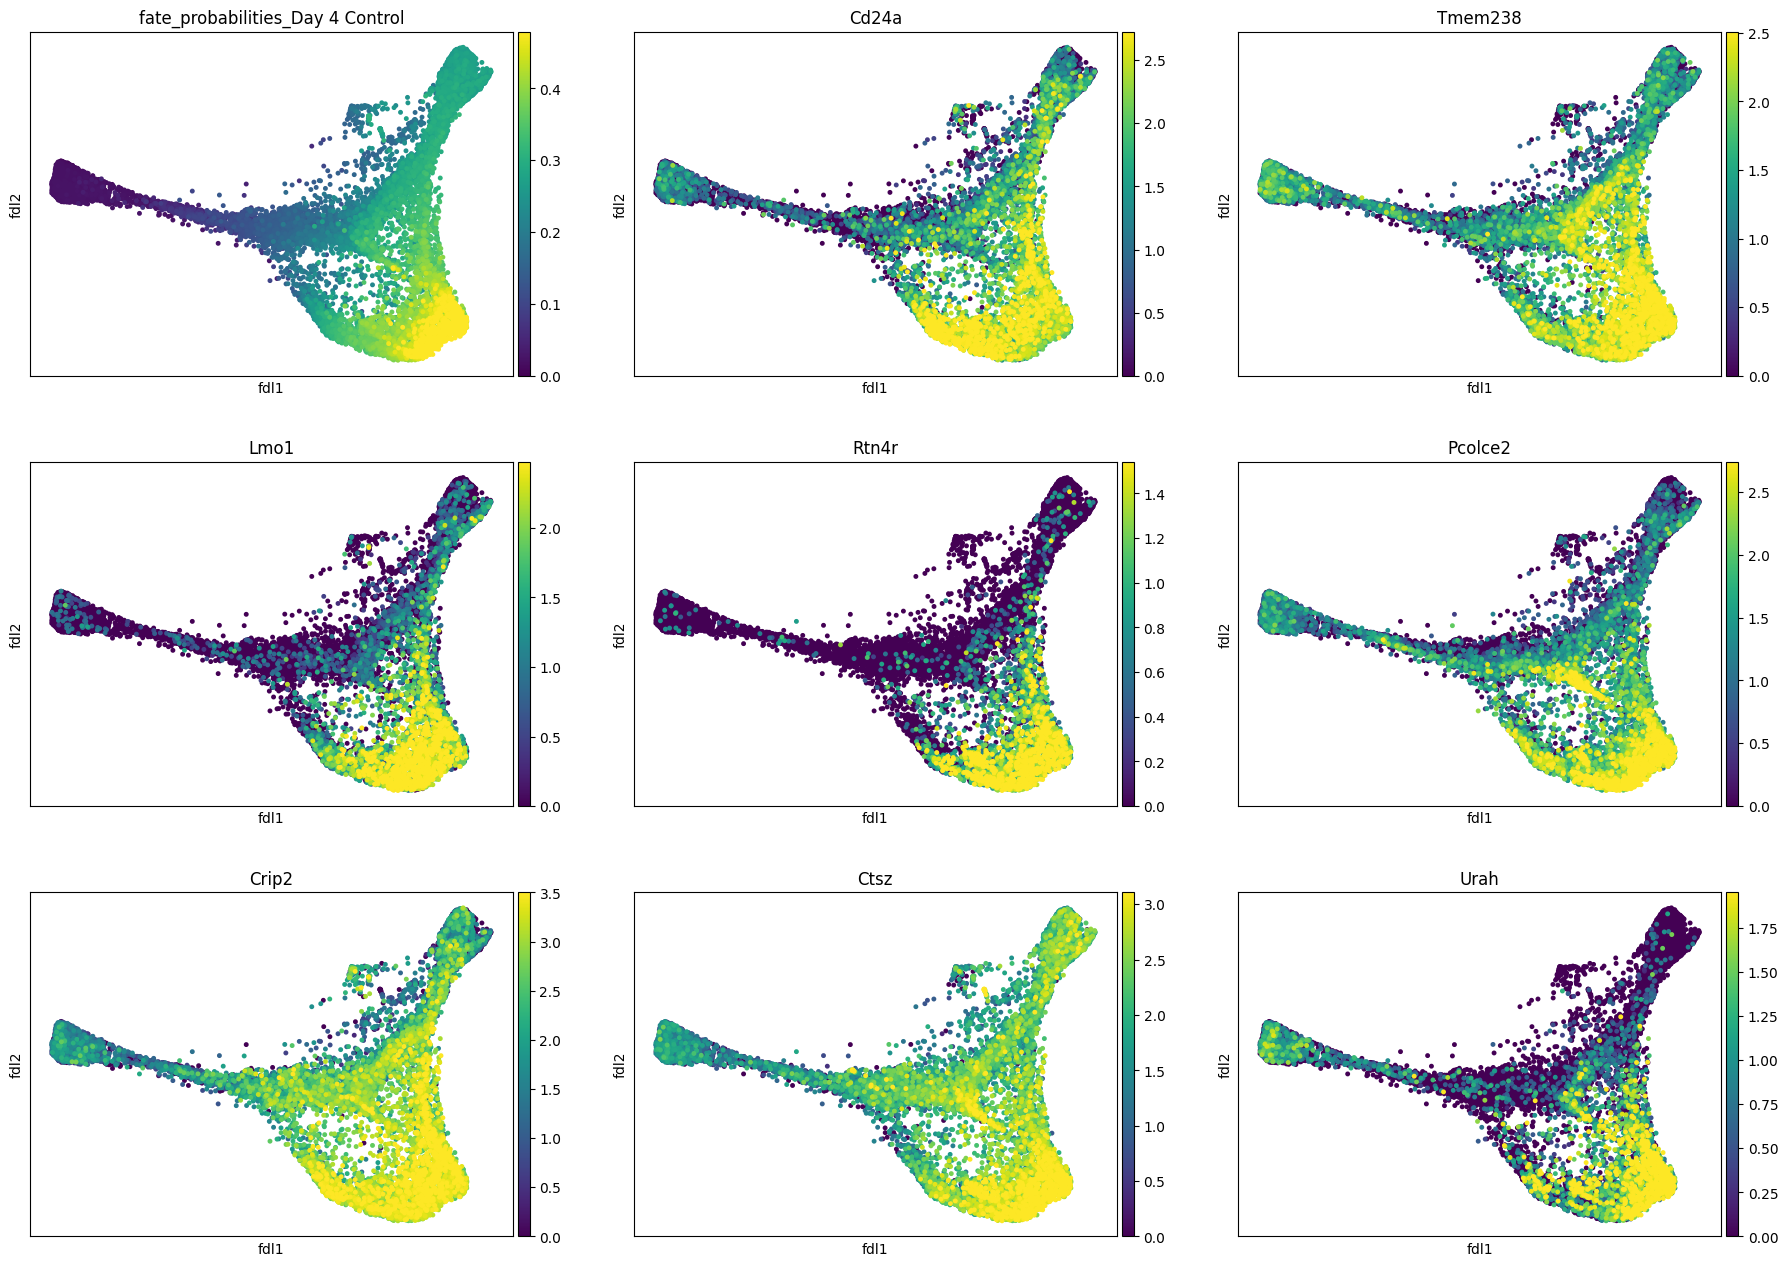

In [31]:
# Visualize driver genes for the control path

terminal_state = "Day 4 Control"
scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=[f"fate_probabilities_{terminal_state}"] + list(driver_df.sort_values(f"{terminal_state}_corr", ascending=False).index[:8]),
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)